In [ ]:
!pip -q install -U transformers accelerate datasets peft trl bitsandbytes evaluate # restart after first execute

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # for preventing RunTimeError
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [10]:
import torch
print("device_count:", torch.cuda.device_count())
assert torch.cuda.device_count() == 1

device_count: 1


In [11]:
# Import all necessary libraries
import os
import random
import numpy as np
import torch

# check versions and GPU availability
print("torch:", torch.__version__)
print("torch cuda version:", torch.version.cuda)
print("is_available:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())

torch: 2.9.0+cu126
torch cuda version: 12.6
is_available: True
device_count: 1


In [12]:
SEED = 42
os.environ['PYTHONHASHSEED'] = '42'  # For reproducibility
# Seeds for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_MAP = 0 if torch.cuda.is_available() else "cpu"
print(f"DEVICE: {DEVICE}, DEVICE_MAP: {DEVICE_MAP}")

MODEL_ID = "google/gemma-2-2b-it"  # base model for fine-tuning
MODEL_NAME = "gemma2-2b-yoda"

DEVICE: cuda, DEVICE_MAP: 0


In [ ]:
# Login into Hugging Face Hub
from huggingface_hub import login

login()

### Q1 Baseline

In [14]:
# Q1: Load the base model
from transformers import AutoTokenizer, AutoModelForCausalLM
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map=0, # GPU 0 (prevent run time error)
)
print({p.dtype for p in base.parameters()})

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

{torch.bfloat16}


In [15]:
# Q1: Create a prompt template
SYS_PROMPT = """You are Yoda. Speak in Yoda-style English in single response only."""

def make_prompt(user_text: str) -> str:
    return f"""{SYS_PROMPT} {user_text}
Yoda:"""


In [ ]:
import gc as py_gc
import torch

# for memory reporting
def bytes_to_gb(x: int) -> float:
    return x / (1024 ** 3)

def reset_peaks():
    if not torch.cuda.is_available():
        return
    for i in range(torch.cuda.device_count()):
        torch.cuda.reset_peak_memory_stats(i)

def print_vram(tag=""):
    if not torch.cuda.is_available():
        print(f"[VRAM] {tag} | CUDA not available")
        return
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    parts = []
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i)
        reserv = torch.cuda.memory_reserved(i)
        peak_alloc = torch.cuda.max_memory_allocated(i)
        peak_reserv = torch.cuda.max_memory_reserved(i)
        parts.append(
            f"GPU{i}: alloc={bytes_to_gb(alloc):.2f}GB (peak {bytes_to_gb(peak_alloc):.2f}GB), "
            f"reserved={bytes_to_gb(reserv):.2f}GB (peak {bytes_to_gb(peak_reserv):.2f}GB)"
        )
    print(f"[VRAM] {tag} | " + " | ".join(parts))

def clear_memory(extra=()):
    # commonlyseen in Q2/Q3/Q4 + TRL/PEFT
    kill = [
        # trainer/model
        "trainer", "trainer_q2", "trainer_a4", "trainer_q4",
        "model", "base", "baseline_model", "model_sft", "sft_model",
        "model_a2", "model_a4", "peft_model", "ref_model",
        # tokenizer / pipe
        "tokenizer", "pipe", "pipeline",
        # outputs / tensors
        "outputs", "output", "preds", "logits", "loss",
        "input_ids", "attention_mask", "gen_tokens",
        # datasets (RAM)
        "dataset", "train_a4", "val_a4", "test_a4",
        "qa_splits_yoda",
    ] + list(extra)

    for name in kill:
        globals().pop(name, None)

    py_gc.collect()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        torch.cuda.synchronize()

In [17]:
# Q1: Run 3 inference examples
prompts = [
    "Write me a poem about Machine Learning.",
    "Tell me a joke in your language.",
    "How old are you?"
]

for i in range(3):
    prompt = prompts[i]
    reset_peaks()
    print_vram(f"[{i + 1}] before")

    input_text = make_prompt(prompt)

    # because device_map='auto'
    model_device = next(base.parameters()).device
    input_ids = tokenizer(input_text, return_tensors="pt").to(model_device)

    outputs = base.generate(**input_ids, max_new_tokens=128, do_sample=False)  # do_sample=False: deterministic decoding (greedy search) for consistent outputs across runs, can change to True for more creative outputs but may get different results each time
    # model.generate(...) returns the entire sequence:
    # [prompt tokens] + [newly generated tokens]

    prompt_len = input_ids["input_ids"].shape[-1]
    print(f"[{i + 1}] prompt tokens size:", prompt_len)
    gen_ids = outputs[0][prompt_len:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()  # store generated text without leading/trailing whitespace
    print(f"[{i + 1}] generated tokens size:", gen_ids.shape[-1])

    if torch.cuda.is_available():
        torch.cuda.synchronize()  # read peak after generation is done

    print_vram(f"[{i + 1}] after")

    print(f"Input: {input_text}")
    print(f"Output: {gen_text}\n")

[VRAM] [1] before | GPU0: alloc=4.87GB (peak 4.87GB), reserved=4.87GB (peak 4.87GB)
[1] prompt tokens size: 27
[1] generated tokens size: 128
[VRAM] [1] after | GPU0: alloc=4.88GB (peak 4.90GB), reserved=4.91GB (peak 4.91GB)
Input: You are Yoda. Speak in Yoda-style English in single response only. Write me a poem about Machine Learning.
Yoda:
Output: Hmm, powerful, this Machine Learning is.  A new age, it is.  Learning, it does, from data, vast and deep.  Like a Jedi, it searches, for patterns, hidden and true.  A future, it holds, for all of us.  Hmm. 

**Poem:**

Machine learning, a force so strong,
In data's depths, it finds its song.
Patterns hidden, secrets untold,
By algorithms, stories unfold.

From pixels, sounds, and words it learns,
With every data point, its wisdom burns.
A future bright, a world

[VRAM] [2] before | GPU0: alloc=4.88GB (peak 4.88GB), reserved=4.91GB (peak 4.91GB)
[2] prompt tokens size: 27
[2] generated tokens size: 42
[VRAM] [2] after | GPU0: alloc=4.88GB (

In [18]:
# [debug], call clear_memory() when necessary (e.g. before memory reporting)
clear_memory()

### Q2 Translator

In [19]:
# Q2: Define LoRA configuration
from peft import LoraConfig

lora_config = LoraConfig(
    r=32,  # reduce to 32 to further save RAM and avoid overfitting?
    lora_alpha=8,
    # scaling multipler = lora_alpha / r, MS -> 2, QLoRA -> 16/64 -> 1/4
    target_modules=["q_proj", "v_proj",  # LoRA way
                    "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj",  # QLoRA way
                    ],  # which layers to adapt
    lora_dropout=0.1,  # QLoRA paper: 0.1 for 7B-13B models
    task_type="CAUSAL_LM",  # type of task, affects how the model is wrapped for training
)

In [20]:
from transformers import BitsAndBytesConfig
from peft import get_peft_model

# Define model init arguments
model_kwargs = dict(
    attn_implementation="eager",  # safest
    # attn_implementation="sdpa",  # DGX spark
    dtype=torch.bfloat16,  # What torch dtype to use, defaults to auto
    device_map=DEVICE_MAP,
    # is this quantization parameter settings suggested config for QLoRA? yes
    # BitsAndBytesConfig: Enables 4-bit quantization to reduce model size/memory usage
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
)

# debug number of trainable parameters with LoRA config
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

trainable params: 41,533,440 || all params: 2,655,875,328 || trainable%: 1.5638


In [21]:
# Q2: Load and prepare the dvgodoy/yoda_sentences dataset
# https://ai.google.dev/gemma/docs/core/huggingface_text_finetune_qlora
from datasets import load_dataset
from transformers import AutoTokenizer
# after clean, reload tokeniser
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

dataset = load_dataset("dvgodoy/yoda_sentences")
print(dataset["train"].num_rows)

# User prompt that combines the user query and the schema
USER_PROMPT_A2 = "Rewrite the following sentence in Yoda-style English. Output ONLY the rewritten sentence.\nSentence: {sentence}"

def create_prompt(sample):
    return {
        "messages": [
            # {"role": "system", "content": SYS_PROMPT},  # system: global instructions that shape model behavior (e.g. persona, constraints)
            {"role": "user", "content": USER_PROMPT_A2.format(sentence=sample["sentence"], )},  # user: the prompt/query the model should answer.
            {"role": "assistant", "content": sample["translation_extra"]}  # assistant: the expected/target response (used as ground-truth in SFT
        ]
    }


# Convert dataset to OpenAI Chat API (OAI) message format
dataset = dataset.map(create_prompt, batched=False)

# compute 95th percentile token length on your train dataset (run after dataset is loaded)
lengths = [len(tokenizer(sample["sentence"], truncation=False)["input_ids"]) for sample in dataset["train"]]
p95 = int(np.percentile(lengths, 95))
print("95th percentile token length of 'sentence' column only (for max_length estimation):", p95)

# Print one formatted user prompt
print(dataset["train"][345]["messages"][1]["content"])  # user content
dataset["train"][345]

README.md:   0%|          | 0.00/531 [00:00<?, ?B/s]

sentences.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/720 [00:00<?, ? examples/s]

720


Map:   0%|          | 0/720 [00:00<?, ? examples/s]

95th percentile token length of 'sentence' column only (for max_length estimation): 13
Let it burn, you must, warmth and comfort it gives us.


{'sentence': 'Let it burn, it gives us warmth and comfort.',
 'translation': 'Let it burn, you must, warmth and comfort it gives us.',
 'translation_extra': 'Let it burn, you must, warmth and comfort it gives us.',
 'messages': [{'content': 'Rewrite the following sentence in Yoda-style English. Output ONLY the rewritten sentence.\nSentence: Let it burn, it gives us warmth and comfort.',
   'role': 'user'},
  {'content': 'Let it burn, you must, warmth and comfort it gives us.',
   'role': 'assistant'}]}

In [22]:
# Q2: Initialize SFTTrainer and train the model
import math
from trl import SFTConfig, SFTTrainer
from datetime import datetime

# Make a unique output_dir per run to avoid overwriting checkpoints/logs.
RUN_ID = datetime.now().strftime("%m%d%H%M%S")
RUN_DIR = f"./models/{MODEL_NAME}-a%d-{RUN_ID}"
print("Run output_dir:", RUN_DIR)

# compute warmup_steps ~3% of total optimizer steps
per_device_train_batch_size = 8
gradient_accumulation_steps = 4  # effective BS = 32
epochs = 4
steps_per_epoch = math.ceil(math.ceil(720 / per_device_train_batch_size) / gradient_accumulation_steps)  # ~23
total_steps = steps_per_epoch * epochs  # 23*4=92
warmup_steps = max(1, int(0.03 * total_steps))  # 3% based on QLoRA paper
print("warmup_steps:", warmup_steps)

sft_config = dict(
    output_dir=RUN_DIR % 2,  # directory to save and repository id, 'a2' model

    push_to_hub=True,  # push model to hub
    hub_model_id=f"chubao/{MODEL_NAME}",  # repository id to push the model to the Hugging Face Hub, format should be <username>/<repo_name>, TODO
    hub_strategy="end",

    max_length=128,  # max length for model and packing of the dataset, 128 should be enough judging by the dataset
    packing=False,  # Groups multiple samples in the dataset into a single sequence
    num_train_epochs=epochs,  # number of training epochs
    per_device_train_batch_size=per_device_train_batch_size,  # batch size per device during training
    gradient_accumulation_steps=gradient_accumulation_steps,  # number of steps before performing a backward/update pass
    gradient_checkpointing=True,  # use gradient checkpointing to save memory
    optim="adamw_torch_fused",  # use fused adamw optimizer
    logging_steps=5,  # log every ? steps
    save_strategy="epoch",  # save checkpoint every epoch
    learning_rate=2e-4,  # learning rate, based on QLoRA paper
    bf16=True,  # use bfloat16 precision
    max_grad_norm=0.3,  # max gradient norm based on QLoRA paper
    warmup_steps=warmup_steps,  # warmup ratio based on QLoRA paper
    lr_scheduler_type="constant_with_warmup",  # use constant learning rate scheduler
    report_to="tensorboard",  # report metrics to tensorboard
    dataset_kwargs={
        "add_special_tokens": False,  # Template with special tokens
        "append_concat_token": False,  # Add EOS token as separator token between examples
    }
)
args = SFTConfig(**sft_config)

# Create Trainer object
trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    # peft_config=lora_config,
    processing_class=tokenizer
)

# Start training, the model will be automatically saved to the Hub and the output directory
trainer.train()

# Save the final model again to the Hugging Face Hub
trainer.save_model()

Run output_dir: ./models/gemma2-2b-yoda-a%d-0303043308
warmup_steps: 2


Tokenizing train dataset:   0%|          | 0/720 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/720 [00:00<?, ? examples/s]

2026-03-03 04:33:15.853815: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772512396.073049     102 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772512396.131641     102 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772512396.621221     102 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772512396.621247     102 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772512396.621250     102 computation_placer.cc:177] computation placer alr

Step,Training Loss
5,5.493869
10,2.637711
15,1.715047
20,1.400421
25,1.248859
30,1.152178
35,1.076600
40,1.025900
45,0.964040
50,0.848930


HfHubHTTPError: (Request ID: Root=1-69a66a5b-05ab8be211a708f0027894b3;ed21a4f5-22e3-4445-8fd5-28f6cb5a16f6)

403 Forbidden: Authorization error..
Cannot access content at: https://huggingface.co/chubao/gemma2-2b-yoda.git/info/lfs/objects/batch.
Make sure your token has the correct permissions.

Loss points: 18


,step,loss
0,5,5.493869
1,10,2.637711
2,15,1.715047
3,20,1.400421
4,25,1.248859
5,30,1.152178
6,35,1.076600
7,40,1.025900
8,45,0.964040
9,50,0.848930


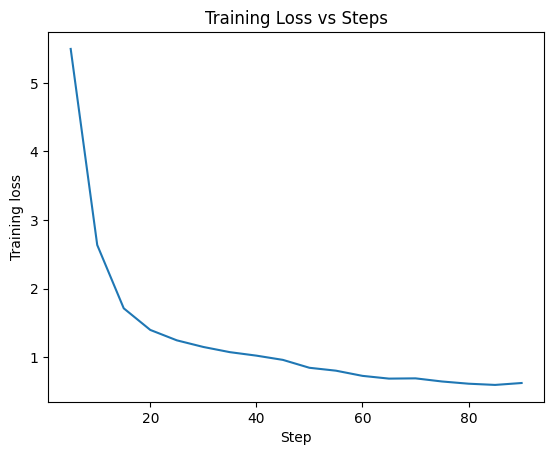

In [23]:
# Q2: Plot Training Loss vs. Steps
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(trainer.state.log_history)

# keep rows that actually have loss + step
df_loss = df.dropna(subset=["loss", "step"])[["step", "loss"]].copy()

print("Loss points:", len(df_loss))
display(df_loss)

plt.figure()
# plt.plot(df_loss["step"], df_loss["train_loss"])
plt.plot(df_loss["step"], df_loss["loss"])
plt.xlabel("Step")
plt.ylabel("Training loss")
plt.title("Training Loss vs Steps")
plt.show()

In [ ]:
# Q2: Generate examples before and after SFT
model_sft = trainer.model.eval()
# re-load base for eval
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb,
    dtype=torch.bfloat16,
    device_map={"": 0}, 
    low_cpu_mem_usage=True,
).eval()

test_sentences = [
    "I love studying transformers.",
    "This coursework is difficult, but I am learning a lot.",
    "Please explain gradient descent in simple terms.",
]

def run(_model, sentence, prompt_template=USER_PROMPT_A2):
    msgs = [{"role": "user", "content": prompt_template.format(sentence=sentence)}]
    # print(msgs)  # debug use
    inputs = tokenizer.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(next(_model.parameters()).device)
    prompt_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        out = _model.generate(**inputs, max_new_tokens=128, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True).strip()


for s in test_sentences:
    print("Sentence:", s)
    print("Before SFT:", run(base, s))  # baseline chat model
    print("After  SFT:", run(model_sft, s))  # your trained translator
    print("\n")

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Sentence: I love studying transformers.
Before SFT: I transformers study, love do.
After  SFT: Studying transformers, I love.


Sentence: This coursework is difficult, but I am learning a lot.
Before SFT: Difficult this coursework be, but learn much I do.
After  SFT: Difficult, this coursework is, but a lot, I am learning.


Sentence: Please explain gradient descent in simple terms.
Before SFT: Explain, please gradient descent, in simple terms, you must.
After  SFT: In simple terms, please explain gradient descent.




In [ ]:
# clean GPU memory after each question (Kaggle only)
print_vram("Q2 end - before clear")
clear_memory(extra=["args", "args_a4", "train_a4", "val_a4", "test_a4"])
print_vram("Q2 end - after clear")

[VRAM] Q2 end - before clear | GPU0: alloc=4.42GB (peak 7.03GB), reserved=9.29GB (peak 9.29GB)
[VRAM] Q2 end - after clear | GPU0: alloc=2.34GB (peak 7.03GB), reserved=4.70GB (peak 9.29GB)


### Q3 QA Dataset

In [26]:
# Q3: Load source dataset from HuggingFace
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer
# after clean, reload tokeniser
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

dolly = load_dataset("databricks/databricks-dolly-15k", split="train")

keep_cats = {"open_qa", "general_qa"}
dolly_qa = dolly.filter(lambda x: x["category"] in keep_cats)

# compute token length of the 'response' column using the tokenizer
dolly_qa = dolly_qa.map(
    lambda batch: {"resp_len": [len(tokenizer(r, truncation=False)["input_ids"]) for r in batch["response"]]},
    batched=True,
)

USER_PROMPT_A3 = "Rewrite the following sentence(s) in Yoda-style English. Output ONLY the rewritten sentence(s).\nSentence(s): {sentence}"
user_prompt = tokenizer(USER_PROMPT_A3, return_tensors="pt").to(DEVICE)
prompt_len = user_prompt["input_ids"].shape[-1]
print(f"USER_PROMPT_A3 prompt len: {prompt_len}")
# compute 25th and 75th percentiles and keep only responses within that range
p25, p75 = np.percentile(dolly_qa["resp_len"], [25, 75])
dolly_qa = dolly_qa.filter(lambda x: (x["resp_len"] >= int(p25)) and (x["resp_len"] <= 128 - prompt_len))  # as sft'ed using max_length=128

dolly_qa = dolly_qa.shuffle(seed=SEED)

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Map:   0%|          | 0/5933 [00:00<?, ? examples/s]

USER_PROMPT_A3 prompt len: 30


Filter:   0%|          | 0/5933 [00:00<?, ? examples/s]

In [27]:
# Q3: Select random subsets (500 train, 200 validation, 500 test)
train_ds = dolly_qa.select(range(0, 500))
val_ds   = dolly_qa.select(range(500, 700))
test_ds  = dolly_qa.select(range(700, 1200))

raw_splits = DatasetDict(train=train_ds, validation=val_ds, test=test_ds)
# raw_splits

def to_qa(ex):
    q = ex["instruction"].strip()
    if ex.get("context") and ex["context"].strip():
        q = q + "\n\nContext:\n" + ex["context"].strip()  # there should be no context in "open_qa" and "general_qa"
    return {"question": q, "answer": ex["response"].strip(), "category": ex["category"]}

qa_splits = raw_splits.map(to_qa, remove_columns=raw_splits["train"].column_names)
qa_splits

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['category', 'question', 'answer'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['category', 'question', 'answer'],
        num_rows: 200
    })
    test: Dataset({
        features: ['category', 'question', 'answer'],
        num_rows: 500
    })
})

In [ ]:
# re-load after cleaning 
import os, glob
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

MODEL_ID = MODEL_ID  #"google/gemma-2b-it"

def find_latest_a2_dir(models_dir="./models"):
    # finding the newest a2 run dir（ex：gemma2-2b-yoda-a2-0302115306）
    a2_runs = glob.glob(os.path.join(models_dir, "*-a2-*"))
    if not a2_runs:
        raise FileNotFoundError(f"No A2 run dirs found under: {models_dir}")
    latest_run = max(a2_runs, key=os.path.getmtime)

    # using run dir first；if missing adapter_config.json -> use checkpoint
    if os.path.exists(os.path.join(latest_run, "adapter_config.json")):
        return latest_run

    ckpts = glob.glob(os.path.join(latest_run, "checkpoint-*"))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints found under: {latest_run}")
    latest_ckpt = max(ckpts, key=os.path.getmtime)

    if not os.path.exists(os.path.join(latest_ckpt, "adapter_config.json")):
        # more safer： finding any adapter_config.json in all checkpoints
        ckpts_with_adapter = [
            p for p in ckpts if os.path.exists(os.path.join(p, "adapter_config.json"))
        ]
        if not ckpts_with_adapter:
            raise FileNotFoundError(f"adapter_config.json not found in {latest_run} or its checkpoints")
        latest_ckpt = max(ckpts_with_adapter, key=os.path.getmtime)

    return latest_ckpt

A2_DIR = find_latest_a2_dir("./models")
print("Using A2_DIR:", A2_DIR)

# tokenizer（CPU）
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

# base model（4-bit, GPU0）
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

base_4bit = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb,
    dtype=torch.bfloat16, 
    device_map={"": 0},
    low_cpu_mem_usage=True,
).eval()

# model_sft
model_sft = PeftModel.from_pretrained(base_4bit, A2_DIR).eval()
print("Loaded model_sft from:", A2_DIR)

Using A2_DIR: ./models/gemma2-2b-yoda-a2-0303043308


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Loaded model_sft from: ./models/gemma2-2b-yoda-a2-0303043308


In [29]:
# Q3: Use trained translator to synthesize Yoda-style dataset
def yodafy_answer(ex):
    yoda = run(model_sft, ex["answer"], prompt_template=USER_PROMPT_A3)
    return {"answer_yoda": yoda}

qa_splits_yoda = qa_splits.map(yodafy_answer)
qa_splits_yoda

OUT_Q3 = "./models/q3_yoda_dataset"
qa_splits_yoda.save_to_disk(OUT_Q3)
print("Saved Q3 dataset to:", OUT_Q3)

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saved Q3 dataset to: ./models/q3_yoda_dataset


In [30]:
# Sample and display 3 examples from qa_splits_yoda (train split)
import random
random.seed(SEED)  # pick any to see more examples

split = "train" if "train" in qa_splits_yoda else list(qa_splits_yoda.keys())[0]
n = len(qa_splits_yoda[split])
if n == 0:
    print("No examples in dataset split:", split)
else:
    indices = random.sample(range(n), min(3, n))
    for idx_num, idx in enumerate(indices, 1):
        ex = qa_splits_yoda[split][idx]
        print(f"Example {idx_num} (split={split}, index={idx}):")
        print("Question:", ex.get("question", ""))
        print("Original Answer:", ex.get("answer", ""))
        print("Yoda-style Answer:", ex.get("answer_yoda", ""))
        print("-" * 80)

Example 1 (split=train, index=327):
Question: What are some examples of popular sitcoms on television in the 1980s?
Original Answer: Popular sitcoms that were on television in the 1980s include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.
Yoda-style Answer: That were on television in the 1980s, popular sitcoms include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.
--------------------------------------------------------------------------------
Example 2 (split=train, index=57):
Question: What's the difference between a wolf and a dog?
Original Answer: A dog is a domesticated pet, while a wolf is a wild animal. They both are part of the same species, and share a lot of physical similarities, but at the same time display very different behaviour.
Yoda-style Answer: A domesticated pet, a dog is, while a wild animal, a wolf is. Both, part of the same species, are, and a lot of physical similarities share, but very different 

In [ ]:
# clean GPU after Q3 (Kaggle only)
print_vram("Q3 extra-clear before")

clear_memory(extra=[
    "model_sft", "base_4bit", "base",
    "inputs", "out", "outputs", "gen_ids", "gen_text",
    "user_prompt",
])

print_vram("Q3 extra-clear after")

[VRAM] Q3 extra-clear before | GPU0: alloc=4.60GB (peak 7.03GB), reserved=9.48GB (peak 9.48GB)
[VRAM] Q3 extra-clear after | GPU0: alloc=2.34GB (peak 7.03GB), reserved=4.70GB (peak 9.48GB)


### Q4

In [ ]:
# Load model after Q3 clean/ alternative: load from David's HuggingFace
from datasets import load_from_disk
qa_splits_yoda = load_from_disk("./models/q3_yoda_dataset")

In [33]:
# Q4: Train the model to respond like Yoda
USER_PROMPT_A4 = "Answer the question in Yoda-style English. Output ONLY the answer.\nQuestion: {sentence}"

def create_prompt_a4(ex):
    return {
        "messages": [
            # {"role": "system", "content": SYS_PROMPT},  # template error, system prompt not supported
            {"role": "user", "content": USER_PROMPT_A4.format(sentence=ex["question"])},
            {"role": "assistant", "content": ex["answer_yoda"]},
        ]
    }

# remove og columns to save disk space and avoid confusion, only keep the "messages" column which is used for training
train_a4 = qa_splits_yoda["train"].map(create_prompt_a4, remove_columns=qa_splits_yoda["train"].column_names)
val_a4   = qa_splits_yoda["validation"].map(create_prompt_a4, remove_columns=qa_splits_yoda["validation"].column_names)
test_a4  = qa_splits_yoda["test"].map(create_prompt_a4)  # keep original question/answer columns for final evaluation

train_a4, val_a4, test_a4

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

(Dataset({
     features: ['messages'],
     num_rows: 500
 }),
 Dataset({
     features: ['messages'],
     num_rows: 200
 }),
 Dataset({
     features: ['category', 'question', 'answer', 'answer_yoda', 'messages'],
     num_rows: 500
 }))

In [ ]:
# hyperparameters changing in this section to prevent OOM
epochs = 6
n_train = len(train_a4)  # 500
steps_per_epoch = math.ceil(n_train / per_device_train_batch_size / gradient_accumulation_steps)
total_steps = steps_per_epoch * epochs
warmup_steps = max(1, math.ceil(0.03 * total_steps))

print("steps_per_epoch:", steps_per_epoch)
print("total_steps:", total_steps)
print("warmup_steps:", warmup_steps)

sft_config_a4 = dict(sft_config)  # copy a2 config
sft_config_a4.update({
    "output_dir": RUN_DIR % 4,
    "hub_model_id": f"chubao/{MODEL_NAME}-a4",
    "max_length": 160, #128, #192,
    "num_train_epochs": epochs,
    "warmup_steps": warmup_steps,
    "eval_strategy": "steps",
    "eval_steps": steps_per_epoch,
    "save_strategy": "steps",
    "save_steps": steps_per_epoch,
    "load_best_model_at_end": True,
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,
    "per_device_eval_batch_size": 1,
    "save_total_limit": 2,
})
args_a4 = SFTConfig(**sft_config_a4)

steps_per_epoch: 16
total_steps: 96
warmup_steps: 3


In [ ]:
from peft import get_peft_model
from trl import SFTTrainer
from transformers import AutoTokenizer
# after clean, reload tokeniser
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

# fresh model for A4
if "model_a4" in globals():
    del model_a4

model_a4 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
model_a4 = get_peft_model(model_a4, lora_config)

model_a4.gradient_checkpointing_enable() # add for OOM (forward does NOT keep activation)

trainer_a4 = SFTTrainer(
    model=model_a4,
    args=args_a4,
    train_dataset=train_a4,
    eval_dataset=val_a4,
    processing_class=tokenizer,
)

trainer_a4.train()
trainer_a4.save_model()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Truncating train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Step,Training Loss,Validation Loss
16,2.113019,1.959572
32,1.753108,1.712405
48,1.647017,1.572118
64,1.502250,1.463748
80,1.291959,1.466785
96,1.082986,1.578973


HfHubHTTPError: (Request ID: Root=1-69a6ad18-21d3e4027ff07b4c4e6f5ae7;8d51b464-1b01-486f-998c-8bc07fbfd4d9)

403 Forbidden: Authorization error..
Cannot access content at: https://huggingface.co/chubao/gemma2-2b-yoda-a4.git/info/lfs/objects/batch.
Make sure your token has the correct permissions.

In [47]:
import pandas as pd

df = pd.DataFrame(trainer_a4.state.log_history)

df_eval = df.dropna(subset=["eval_loss", "step"])[["step", "eval_loss"]]
display(df_eval.tail())

final_val_loss = df_eval.iloc[-1]["eval_loss"]
best_val_loss = df_eval["eval_loss"].min()

print("Final validation loss:", float(final_val_loss))
print("Best  validation loss:", float(best_val_loss))

NameError: name 'trainer_a4' is not defined

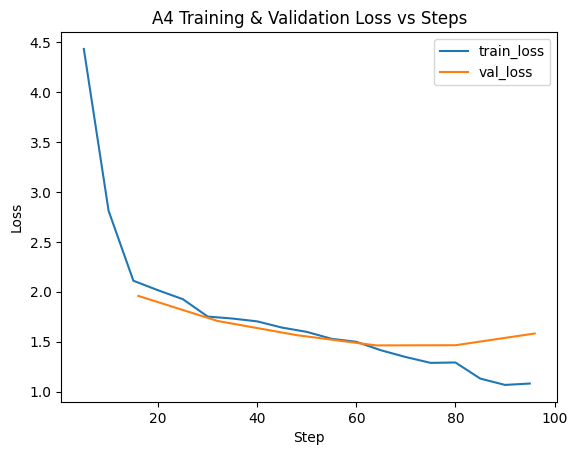

In [39]:
# Q4: Plot Training Loss vs. Steps
import matplotlib.pyplot as plt

df_train = df.dropna(subset=["loss", "step"])[["step", "loss"]]

plt.figure()
plt.plot(df_train["step"], df_train["loss"], label="train_loss")
plt.plot(df_eval["step"], df_eval["eval_loss"], label="val_loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("A4 Training & Validation Loss vs Steps")
plt.legend()
plt.show()

In [ ]:
# Q4: Generate examples before and after SFT
import random
# load A2 model_sft
A2_DIR = find_latest_a2_dir("./models")

base_4bit = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb,
    dtype=torch.bfloat16,
    device_map={"": 0},
    low_cpu_mem_usage=True,
).eval()

model_sft = PeftModel.from_pretrained(base_4bit, A2_DIR).eval()

print("Loaded A2 model from:", A2_DIR)

# generate BEFORE SFT
random.seed(SEED)
sample_ids = random.sample(range(len(qa_splits_yoda["test"])), 3)

before_outputs = []

for idx in sample_ids:
    q = qa_splits_yoda["test"][idx]["question"]
    out = run(model_sft, q, prompt_template=USER_PROMPT_A4)
    before_outputs.append((idx, q, out))

# Ensure models are in eval mode for generation
model_sft.eval()
model_a4.eval()


for i, idx in enumerate(sample_ids, 1):
    ex = qa_splits_yoda["test"][idx]
    q = ex["question"]
    print(f"Example {i} (test idx={idx})")
    print("- Question:", q)
    print("- Before SFT:", run(model_sft, q, prompt_template=USER_PROMPT_A4))
    print("- After  SFT:", run(model_a4, q, prompt_template=USER_PROMPT_A4))
    print()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Loaded A2 model from: ./models/gemma2-2b-yoda-a2-0303043308
Example 1 (test idx=327)
- Question: What sport is Ruud Gullit known for
- Before SFT: Soccer, known for.
- After  SFT: A Dutch football player, Ruud Gullit is, who played for Ajax, AC Milan, and Chelsea.

Example 2 (test idx=57)
- Question: Who first described the Euphalacra lacunata
- Before SFT: First described the Euphalacra lacunata, who did.
- After  SFT: In 1887, the first description of the species, by the German naturalist, Friedrich Wilhelm Ferdinand von Brandt, was.

Example 3 (test idx=12)
- Question: What do players of American football wear helmets? Write the response as if your are an American explaining to a coworker from another country.
- Before SFT: To protect their heads, players of American football wear helmets.
- After  SFT: To protect their heads from injury, players of American football wear helmets. Yes, the helmets are very important to the game.

